[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/balloontip/deep-learning/blob/main/chapter-09/09-15-Diffusion-Model-MNIST-Digit-Generation.ipynb)

Mini Project: Building a Simple Diffusion Model from Scratch on MNIST. Build and train a simplified diffusion model in PyTorch that learns to generate handwritten digits by progressively removing Gaussian noise from random inputs. This end-to-end project demonstrates the forward and reverse diffusion processes, sinusoidal timestep embeddings, a U-Net denoising network, noise prediction, iterative image generation, and visualization of newly synthesized MNIST digits. :contentReference[oaicite:0]{index=0}

Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 62.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.71MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.9MB/s]


Starting training...


Epoch 1/5: 100%|██████████| 469/469 [09:53<00:00,  1.27s/it, batch_loss=0.1207]


Epoch [1/5], Average Loss: 0.1837


...

Epoch 4/5: 100%|██████████| 469/469 [09:44<00:00,  1.25s/it, batch_loss=0.0737]


Epoch [4/5], Average Loss: 0.0728


Epoch 5/5: 100%|██████████| 469/469 [09:42<00:00,  1.24s/it, batch_loss=0.0751]


Epoch [5/5], Average Loss: 0.0708
Training finished!

Starting image generation...


Generating images: 100%|██████████| 100/100 [00:06<00:00, 16.31it/s]


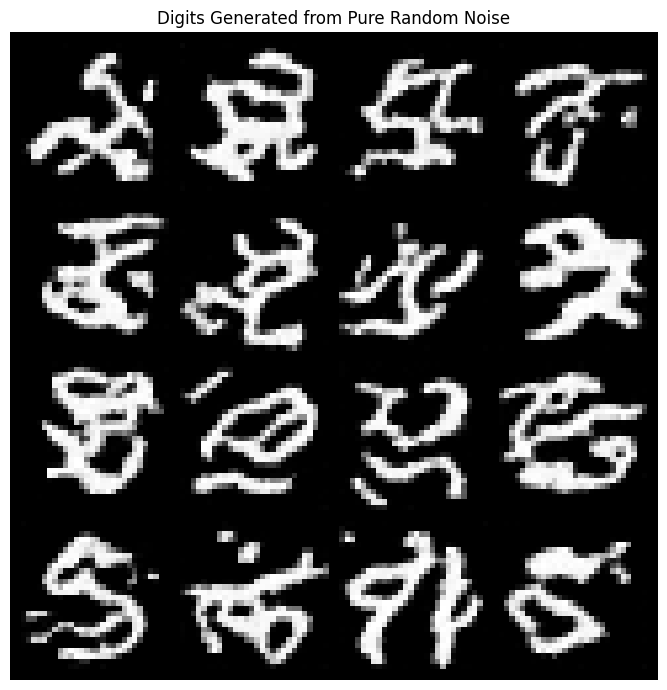

Generation complete. The displayed images were created from pure random noise.


In [2]:
import math

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST
from torchvision.utils import make_grid
from tqdm import tqdm

# -------------------------------------------------------
# Simplified Educational Diffusion Model on MNIST
#
# Workflow:
# 1. Load clean handwritten digits.
# 2. Add a randomly selected amount of Gaussian noise.
# 3. Train a U-Net to predict the noise.
# 4. Start with pure noise.
# 5. Remove predicted noise step by step.
# 6. Display newly generated handwritten digits.
# -------------------------------------------------------

# -------------------------------------------------------
# 1. Reproducibility and Device
# -------------------------------------------------------
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -------------------------------------------------------
# 2. Diffusion Parameters
# -------------------------------------------------------
# T is the number of diffusion steps.
#
# During training:
#     t = 0 means the image contains very little noise.
#     t = T - 1 means the image contains much more noise.
#
# During generation, the model reverses these steps from
# T - 1 down to 0.
T = 100

# beta controls how much new noise is introduced at each step.
# The schedule begins with a very small value and gradually
# increases the amount of noise.
betas = torch.linspace(0.0001, 0.02, T, device=device)

# alpha represents how much signal remains after one step.
alphas = 1.0 - betas

# alpha_bars stores the cumulative product:
#
# alpha_bar[t] = alpha[0] × alpha[1] × ... × alpha[t]
#
# It tells us how much of the original image remains after
# repeatedly applying the forward diffusion process up to step t.
alpha_bars = torch.cumprod(alphas, dim=0)

# -------------------------------------------------------
# 3. Timestep Embedding
# -------------------------------------------------------
class SinusoidalTimeEmbedding(nn.Module):
    """
    Converts each diffusion timestep into a numerical vector.

    The model needs this information because removing a small
    amount of noise at an early step is different from removing
    heavy noise at a late step.
    """

    def __init__(self, embedding_dim):
        super().__init__()
        self.embedding_dim = embedding_dim

    def forward(self, timesteps):
        half_dim = self.embedding_dim // 2

        frequencies = torch.exp(
            -math.log(10000)
            * torch.arange(
                half_dim,
                device=timesteps.device,
                dtype=torch.float32
            )
            / max(half_dim - 1, 1)
        )

        angles = timesteps.float().unsqueeze(1) * frequencies.unsqueeze(0)

        embeddings = torch.cat(
            [torch.sin(angles), torch.cos(angles)],
            dim=1
        )

        return embeddings

# -------------------------------------------------------
# 4. U-Net Denoising Model
# -------------------------------------------------------
class UNet(nn.Module):
    """
    A small U-Net that predicts the noise present in an image.

    Inputs:
        x: Noisy image tensor with shape [batch, 1, 28, 28]
        t: Diffusion timestep tensor with shape [batch]

    Output:
        Predicted noise with the same shape as x
    """

    def __init__(self, time_dim=64):
        super().__init__()

        # Convert the timestep into an embedding.
        self.time_embedding = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )

        # These layers transform the timestep embedding so it can
        # be added to feature maps at different U-Net stages.
        self.time_to_enc1 = nn.Linear(time_dim, 32)
        self.time_to_enc2 = nn.Linear(time_dim, 64)
        self.time_to_bottleneck = nn.Linear(time_dim, 128)

        # ----------------------------
        # Contracting Path: Encoder
        # ----------------------------
        self.encoder1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.downsample1 = nn.MaxPool2d(2)  # 28 × 28 -> 14 × 14

        self.encoder2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.downsample2 = nn.MaxPool2d(2)  # 14 × 14 -> 7 × 7

        # ----------------------------
        # Bottleneck
        # ----------------------------
        self.bottleneck = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU()
        )

        # ----------------------------
        # Expanding Path: Decoder
        # ----------------------------
        self.upsample1 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )  # 7 × 7 -> 14 × 14

        # 64 channels from upsampling + 64 from encoder skip connection
        self.decoder1 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.upsample2 = nn.ConvTranspose2d(
            64,
            32,
            kernel_size=2,
            stride=2
        )  # 14 × 14 -> 28 × 28

        # 32 channels from upsampling + 32 from encoder skip connection
        self.decoder2 = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU()
        )

        # Predict one noise value for each input pixel.
        self.final_layer = nn.Conv2d(32, 1, kernel_size=1)

    @staticmethod
    def add_time_embedding(feature_map, time_embedding):
        """
        Reshapes a timestep embedding so it can be added to
        every spatial position in a feature map.
        """
        return feature_map + time_embedding[:, :, None, None]

    def forward(self, x, t):
        time_emb = self.time_embedding(t)

        # Encoder stage 1
        enc1 = self.encoder1(x)
        enc1 = self.add_time_embedding(
            enc1,
            self.time_to_enc1(time_emb)
        )

        # Encoder stage 2
        enc2 = self.encoder2(self.downsample1(enc1))
        enc2 = self.add_time_embedding(
            enc2,
            self.time_to_enc2(time_emb)
        )

        # Bottleneck
        bottleneck = self.bottleneck(self.downsample2(enc2))
        bottleneck = self.add_time_embedding(
            bottleneck,
            self.time_to_bottleneck(time_emb)
        )

        # Decoder stage 1 with skip connection
        dec1 = self.upsample1(bottleneck)
        dec1 = torch.cat([dec1, enc2], dim=1)
        dec1 = self.decoder1(dec1)

        # Decoder stage 2 with skip connection
        dec2 = self.upsample2(dec1)
        dec2 = torch.cat([dec2, enc1], dim=1)
        dec2 = self.decoder2(dec2)

        return self.final_layer(dec2)

# -------------------------------------------------------
# 5. Forward Diffusion Process
# -------------------------------------------------------
def forward_process(x_0, t):
    """
    Adds the correct amount of Gaussian noise for timestep t.

    The closed-form equation lets us jump directly from a clean
    image x_0 to any noisy timestep x_t without performing every
    earlier diffusion step one by one.

    Returns:
        x_t:   Noisy image
        noise: Exact Gaussian noise added to the image
    """

    alpha_bar_t = alpha_bars[t].view(-1, 1, 1, 1)

    noise = torch.randn_like(x_0)

    x_t = (
        torch.sqrt(alpha_bar_t) * x_0
        + torch.sqrt(1.0 - alpha_bar_t) * noise
    )

    return x_t, noise

# -------------------------------------------------------
# 6. Training Loop
# -------------------------------------------------------
def train_model(model, dataloader, optimizer, epochs=5):
    """
    Trains the U-Net to predict the noise added to each image.
    """

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        progress_bar = tqdm(
            dataloader,
            desc=f"Epoch {epoch + 1}/{epochs}"
        )

        for images, _ in progress_bar:
            images = images.to(device)

            # Select a different random noise level for each image.
            t = torch.randint(
                low=0,
                high=T,
                size=(images.size(0),),
                device=device,
                dtype=torch.long
            )

            # Create noisy images and keep the exact noise as the target.
            x_t, true_noise = forward_process(images, t)

            # Predict the noise using both the noisy image and timestep.
            predicted_noise = model(x_t, t)

            # Compare predicted noise with the actual noise.
            loss = nn.functional.mse_loss(
                predicted_noise,
                true_noise
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)

            progress_bar.set_postfix(
                batch_loss=f"{loss.item():.4f}"
            )

        average_loss = total_loss / len(dataloader.dataset)

        print(
            f"Epoch [{epoch + 1}/{epochs}], "
            f"Average Loss: {average_loss:.4f}"
        )

    print("Training finished!")

# -------------------------------------------------------
# 7. Reverse Diffusion: Image Generation
# -------------------------------------------------------
def generate_images(model, num_images=16, shape=(1, 28, 28)):
    """
    Starts with pure Gaussian noise and repeatedly applies the
    learned reverse diffusion process.

    One reverse step is performed for each of the T forward
    diffusion steps.
    """

    model.eval()

    with torch.no_grad():
        # There is no original digit here.
        # Every generated image begins as pure random noise.
        x = torch.randn(
            num_images,
            *shape,
            device=device
        )

        progress_bar = tqdm(
            reversed(range(T)),
            total=T,
            desc="Generating images"
        )

        for t_value in progress_bar:
            # Every image in the batch is currently at the same timestep.
            t = torch.full(
                (num_images,),
                t_value,
                device=device,
                dtype=torch.long
            )

            predicted_noise = model(x, t)

            alpha_t = alphas[t_value]
            alpha_bar_t = alpha_bars[t_value]
            beta_t = betas[t_value]

            # Estimate the mean of the previous, slightly cleaner image.
            x = (
                1.0 / torch.sqrt(alpha_t)
            ) * (
                x
                - (
                    beta_t
                    / torch.sqrt(1.0 - alpha_bar_t)
                ) * predicted_noise
            )

            # Add a small amount of randomness except at the final step.
            # This sampling noise helps create diverse outputs.
            if t_value > 0:
                random_noise = torch.randn_like(x)
                x = x + torch.sqrt(beta_t) * random_noise

        return x

# -------------------------------------------------------
# 8. Visualization
# -------------------------------------------------------
def show_generated_images(images):
    """
    Displays 16 generated images in a 4 × 4 grid.
    """

    # Training images were normalized from [0, 1] to [-1, 1].
    # Convert generated images back to [0, 1] for display.
    images = (images.clamp(-1, 1) + 1) / 2

    grid = make_grid(
        images.cpu(),
        nrow=4,
        padding=2
    )

    plt.figure(figsize=(7, 7))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.title("Digits Generated from Pure Random Noise")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# -------------------------------------------------------
# 9. Main Execution
# -------------------------------------------------------
if __name__ == "__main__":
    # Convert images to tensors, then normalize pixel values:
    #
    # Original range: [0, 1]
    # Normalized range: [-1, 1]
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    mnist_dataset = MNIST(
        root="./data",
        train=True,
        transform=transform,
        download=True
    )

    dataloader = DataLoader(
        mnist_dataset,
        batch_size=128,
        shuffle=True
    )

    model = UNet().to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    print("Starting training...")
    train_model(
        model,
        dataloader,
        optimizer,
        epochs=5
    )

    print("\nStarting image generation...")
    new_images = generate_images(
        model,
        num_images=16,
        shape=(1, 28, 28)
    )

    show_generated_images(new_images)

    print(
        "Generation complete. The displayed images were created "
        "from pure random noise."
    )
